# Interior-Point Barrier Geometry

For linear objective $c^\top x$ and inequality constraints $a_i^\top x < b_i$,
the barrier objective is
$$
\phi_\mu(x)=c^\top x - \mu\sum_i \log(b_i-a_i^\top x).
$$
We compute central-path points over a wide range of $\mu$ and display barrier level sets on a fine grid.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

A = np.array([[1,0], [0,1], [-1,0], [0,-1], [1,1], [-1,1]], float)
b = np.array([1.6, 1.2, 1.4, 1.3, 1.65, 1.4], float)
c = np.array([1.0, 0.6])

def feasible(x):
    return np.all(b - A @ x > 1e-10)

def phi(x, mu):
    s = b - A @ x
    if np.any(s <= 0):
        return np.inf
    return c @ x - mu * np.sum(np.log(s))

def grad_phi(x, mu):
    s = b - A @ x
    return c + mu * (A.T @ (1/s))

def solve_mu(mu, x0=np.array([0.,0.])):
    x = x0.copy()
    for _ in range(260):
        g = grad_phi(x, mu)
        step = 0.08
        for _ in range(18):
            z = x - step*g
            if feasible(z):
                x = z
                break
            step *= 0.5
    return x


In [2]:
mus = np.geomspace(4.0, 1e-3, 14)
path = []
x0 = np.array([0.,0.])
for mu in mus:
    x0 = solve_mu(mu, x0)
    path.append(x0.copy())
path = np.array(path)

N = 280
xx = np.linspace(-1.5, 1.6, N)
yy = np.linspace(-1.4, 1.4, N)
XX, YY = np.meshgrid(xx, yy)
V = np.full_like(XX, np.nan)
mu_ref = 0.08
for i in range(N):
    for j in range(N):
        z = np.array([XX[i,j], YY[i,j]])
        if feasible(z):
            V[i,j] = phi(z, mu_ref)


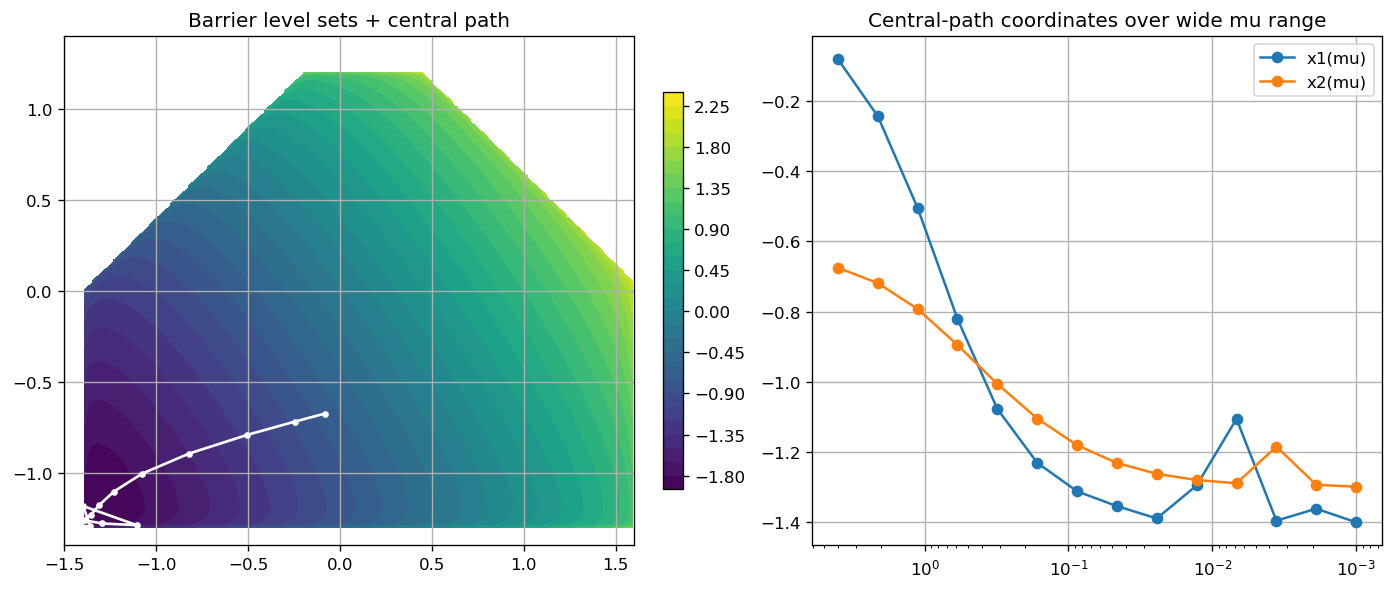

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)
im = axes[0].contourf(XX, YY, V, levels=30, cmap='viridis')
axes[0].plot(path[:,0], path[:,1], 'w.-', lw=1.6)
axes[0].set_title('Barrier level sets + central path')
fig.colorbar(im, ax=axes[0], shrink=0.78)

axes[1].semilogx(mus, path[:,0], 'o-', label='x1(mu)')
axes[1].semilogx(mus, path[:,1], 'o-', label='x2(mu)')
axes[1].invert_xaxis()
axes[1].set_title('Central-path coordinates over wide mu range')
axes[1].legend()
fig.savefig(OUT / "snippet.png", bbox_inches='tight')
plt.show()
